1. Memuat Data 3D untuk Pelatihan...
Data berhasil dimuat!
Bentuk input X_train: (39760, 30, 9) -> (Samples, Timesteps, Features)
Bentuk target y_train: (39760,)

2. Membangun Arsitektur Model BiLSTM...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_1 (Bidirecti  (None, 128)               37888     
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 32)                4128      
                                                                 
 dense_3 (Dense)             (None, 4)                 132       
                                                                 
Total params: 42148 (164.64 KB)
Trainable params:

C:\Users\kunde\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


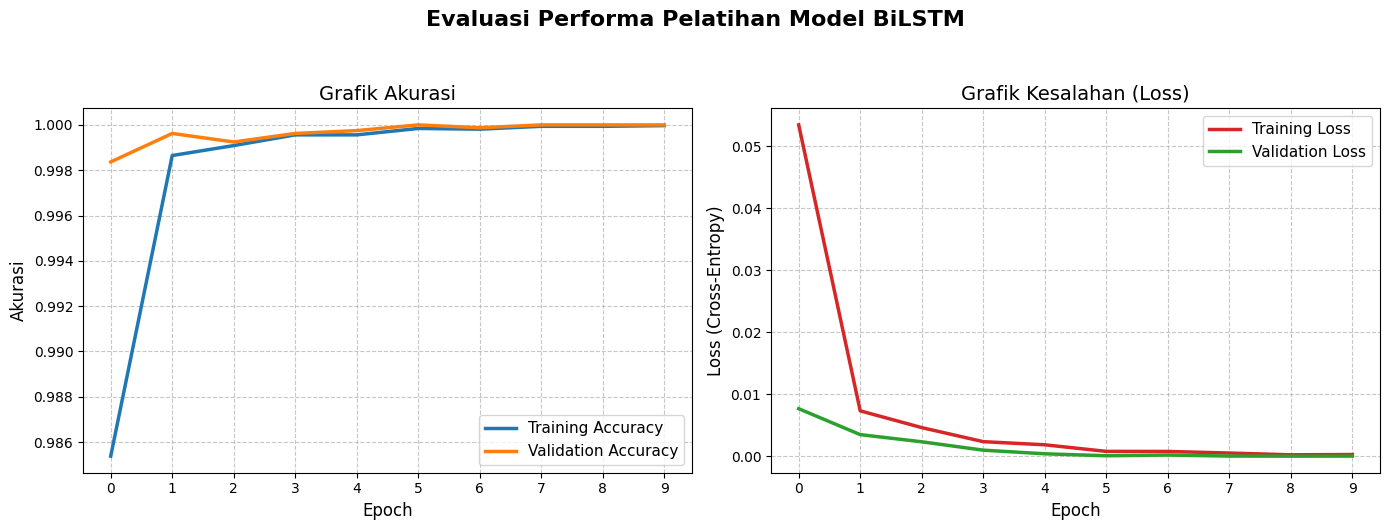


Melakukan simulasi deteksi dengan data acak dari testing set...

🚨 LAPORAN DETEKSI KENDALI SUMUR (Confidence: 100.00%) 🚨
STATUS : KRITIS - ACTUAL GAS KICK (BLOWOUT IMMINENT)
ALASAN : Deteksi pola sangat berbahaya! Terjadi Drilling Break (ROP naik tajam, Gamma Ray turun yang mengindikasi masuknya zona reservoir), dibarengi dengan kenaikan Pit Volume kumulatif, Flow Out melebihi batas 100%, dan penurunan tekanan SPP (U-Tube effect akibat gas ringan).
SARAN MEKANISME :
  1. AKTIFKAN HARD SHUT-IN SEKARANG!
     - Hentikan pemboran, matikan pompa, tutup Annular BOP, lalu buka katup HCR ke Choke Manifold secara perlahan.
     > DAMPAK: Menutup lubang sumur dan menghentikan laju fluida formasi ke permukaan. Tekanan akan terakumulasi dan terbaca di SIDPP & SICP, memungkinkan engineer menghitung berat Kill Mud yang dibutuhkan.
  2. Lakukan sirkulasi pematikan sumur (Driller's Method / Wait & Weight Method).
     > DAMPAK: Gas kick akan dikeluarkan perlahan dengan tekanan terkontrol, mencegah t

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD DATA & PREPARATION
# ==========================================
print("1. Memuat Data 3D untuk Pelatihan...")
try:
    X = np.load('X_features_30_timesteps.npy')
    y = np.load('y_target_labels.npy')
    print("Data berhasil dimuat!")
except FileNotFoundError:
    print("Error: File .npy tidak ditemukan. Pastikan script generate data sebelumnya sudah dijalankan.")
    exit()

# Split data: 80% Training, 20% Testing
# stratify=y memastikan proporsi kelas (normal, kick, dll) seimbang antara train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Bentuk input X_train: {X_train.shape} -> (Samples, Timesteps, Features)")
print(f"Bentuk target y_train: {y_train.shape}")

# ==========================================
# 2. BANGUN ARSITEKTUR MODEL BiLSTM
# ==========================================
print("\n2. Membangun Arsitektur Model BiLSTM...")
model = Sequential([
    # Layer BiLSTM untuk membaca urutan log sumur (maju dan mundur)
    Bidirectional(LSTM(64, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3), # Dropout 30% untuk mencegah overfitting
    Dense(32, activation='relu'),
    # Output layer: 4 neuron sesuai dengan jumlah kelas, menggunakan softmax untuk probabilitas
    Dense(4, activation='softmax') 
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

# ==========================================
# 3. TRAINING MODEL (10 EPOCHS)
# ==========================================
print("\n3. Memulai Pelatihan Model (10 Epochs)...")
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.2, # 20% dari data training digunakan untuk validasi tiap epoch
    verbose=1
)

# Simpan model
model.save('bilstm_blowout_detector.h5')
print("\nModel berhasil dilatih dan disimpan sebagai 'bilstm_blowout_detector.h5'")

# ==========================================
# 4. VISUALISASI HASIL PELATIHAN
# ==========================================
def plot_training_history(history):
    """Menampilkan grafik Akurasi dan Loss dari proses pelatihan model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Evaluasi Performa Pelatihan Model BiLSTM', fontsize=16, fontweight='bold', y=1.05)

    # Grafik Akurasi
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#1F77B4', linewidth=2.5)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF7F0E', linewidth=2.5)
    ax1.set_title('Grafik Akurasi', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Akurasi', fontsize=12)
    ax1.set_xticks(range(0, 10))
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Grafik Loss
    ax2.plot(history.history['loss'], label='Training Loss', color='#D62728', linewidth=2.5)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='#2CA02C', linewidth=2.5)
    ax2.set_title('Grafik Kesalahan (Loss)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
    ax2.set_xticks(range(0, 10))
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Tampilkan grafik pelatihan
plot_training_history(history)

# ==========================================
# 5. SISTEM PAKAR (REASONING & RECOMMENDATION)
# ==========================================
def interpret_and_recommend(model_prediction):
    """
    Sistem pendukung keputusan yang menjelaskan output AI.
    Menghasilkan Alasan, Saran, dan Dampak.
    """
    kelas_prediksi = np.argmax(model_prediction)
    confidence = np.max(model_prediction) * 100
    
    print("\n" + "="*70)
    print(f"🚨 LAPORAN DETEKSI KENDALI SUMUR (Confidence: {confidence:.2f}%) 🚨")
    print("="*70)
    
    if kelas_prediksi == 0:
        print("STATUS : OPERASI NORMAL")
        print("ALASAN : Parameter sirkulasi hidrolik dan mekanis berada dalam rentang stabil. Tidak ada anomali pada pembacaan gas, volume pit, maupun laju aliran keluar.")
        print("SARAN MEKANISME :")
        print("  - Lanjutkan operasi pemboran sesuai parameter (ROP, WOB, RPM) saat ini.")
        print("  - DAMPAK: Operasi berjalan efisien sesuai target kedalaman tanpa Non-Productive Time (NPT).")
        
    elif kelas_prediksi == 1:
        print("STATUS : FALSE ALARM (Connection Gas / Wellbore Ballooning)")
        print("ALASAN : Terdapat fluktuasi sementara pada aliran keluar (Flow Out) dan/atau gas, namun berkorelasi dengan status pompa mati. Ini merupakan efek U-Tube hidrostatik atau pelepasan tekanan formasi jangka pendek, bukan kick berkelanjutan.")
        print("SARAN MEKANISME :")
        print("  1. Circulate Bottoms Up (Sirkulasi penuh tanpa menambah kedalaman).")
        print("     > DAMPAK: Gas sisa akan terdorong keluar. Kondisi lubang bersih, namun menambah sedikit waktu NPT.")
        print("  2. Lakukan Flow Check (Pemantauan aliran statis selama 10-15 menit).")
        print("     > DAMPAK: Memastikan sumur benar-benar mati. Jika aliran terbukti berhenti, pemboran sangat aman untuk dilanjutkan.")

    elif kelas_prediksi == 2:
        print("STATUS : LOST CIRCULATION (Waspada Bahaya Sekunder)")
        print("ALASAN : AI mendeteksi penurunan drastis pada Pit Volume dan Flow Out. Lumpur pemboran terindikasi hilang/terserap ke dalam formasi (kemungkinan zona rekahan atau porositas tinggi).")
        print("SARAN MEKANISME :")
        print("  1. Turunkan kecepatan pompa (Pump Rate/SPM) secara bertahap.")
        print("     > DAMPAK: Mengurangi tekanan ECD (Equivalent Circulating Density) yang memicu robeknya formasi, namun efisiensi pengangkatan cutting bisa menurun.")
        print("  2. Pompakan material penyumbat (Lost Circulation Material / LCM).")
        print("     > DAMPAK: Menyumbat rekahan batuan agar sirkulasi kembali normal. Jika gagal dan volume terus turun, kolom hidrostatik akan berkurang dan dapat memicu Kick (Blowout sekunder).")

    elif kelas_prediksi == 3:
        print("STATUS : KRITIS - ACTUAL GAS KICK (BLOWOUT IMMINENT)")
        print("ALASAN : Deteksi pola sangat berbahaya! Terjadi Drilling Break (ROP naik tajam, Gamma Ray turun yang mengindikasi masuknya zona reservoir), dibarengi dengan kenaikan Pit Volume kumulatif, Flow Out melebihi batas 100%, dan penurunan tekanan SPP (U-Tube effect akibat gas ringan).")
        print("SARAN MEKANISME :")
        print("  1. AKTIFKAN HARD SHUT-IN SEKARANG!")
        print("     - Hentikan pemboran, matikan pompa, tutup Annular BOP, lalu buka katup HCR ke Choke Manifold secara perlahan.")
        print("     > DAMPAK: Menutup lubang sumur dan menghentikan laju fluida formasi ke permukaan. Tekanan akan terakumulasi dan terbaca di SIDPP & SICP, memungkinkan engineer menghitung berat Kill Mud yang dibutuhkan.")
        print("  2. Lakukan sirkulasi pematikan sumur (Driller's Method / Wait & Weight Method).")
        print("     > DAMPAK: Gas kick akan dikeluarkan perlahan dengan tekanan terkontrol, mencegah terjadinya semburan liar di lantai rig. Operasi memakan waktu cukup lama namun sangat aman.")
        print("  3. [Tindakan Darurat Ekstrim] Jika tekanan permukaan melewati Maximum Allowable Surface Pressure (MASP) atau BOP gagal:")
        print("     - Aktifkan Blind Shear Rams.")
        print("     > DAMPAK: Rams akan memotong drill pipe dan menutup sumur secara permanen. Hal ini menyelamatkan nyawa kru dan rig dari ledakan, namun drill string di dalam sumur hancur dan sumur harus dilakukan sidetracking.")
    print("="*70)

# ==========================================
# 6. SIMULASI DETEKSI REAL-TIME
# ==========================================
print("\nMelakukan simulasi deteksi dengan data acak dari testing set...")

# Ambil satu sampel dari skenario Kick (Label 3) di set pengujian untuk memastikan sistem darurat bekerja
kick_indices = np.where(y_test == 3)[0]

if len(kick_indices) > 0:
    sample_idx = kick_indices[0]
    data_input = X_test[sample_idx] # Bentuk: (30, 9)
    data_input_reshaped = np.expand_dims(data_input, axis=0) # Bentuk: (1, 30, 9)
    
    # Model melakukan prediksi
    prediksi = model.predict(data_input_reshaped, verbose=0)
    
    # Panggil fungsi sistem pakar untuk menerjemahkan output AI
    interpret_and_recommend(prediksi)
else:
    print("Tidak ada sampel Kick di test set untuk disimulasikan.")

1. Memuat Data 3D untuk Pelatihan...
   [SUKSES] Data berhasil dimuat!
   Bentuk input X_train: (39760, 30, 9) -> (Samples, Timesteps, Features)
   Bentuk target y_train: (39760,)

2. Membangun Arsitektur Model BiLSTM...

3. Memulai Pelatihan Model (10 Epochs)...
Epoch 1/10
497/497 [==============================] - 11s 16ms/step - loss: 0.0531 - accuracy: 0.9884 - val_loss: 0.0076 - val_accuracy: 0.9984
Epoch 2/10
497/497 [==============================] - 6s 12ms/step - loss: 0.0073 - accuracy: 0.9986 - val_loss: 0.0018 - val_accuracy: 0.9996
Epoch 3/10
497/497 [==============================] - 7s 15ms/step - loss: 0.0028 - accuracy: 0.9994 - val_loss: 6.1204e-04 - val_accuracy: 0.9999
Epoch 4/10
497/497 [==============================] - 6s 13ms/step - loss: 0.0015 - accuracy: 0.9997 - val_loss: 2.6091e-04 - val_accuracy: 0.9999
Epoch 5/10
497/497 [==============================] - 6s 13ms/step - loss: 8.5972e-04 - accuracy: 0.9998 - val_loss: 1.2814e-04 - val_accuracy: 1.0000
Epoc

C:\Users\kunde\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


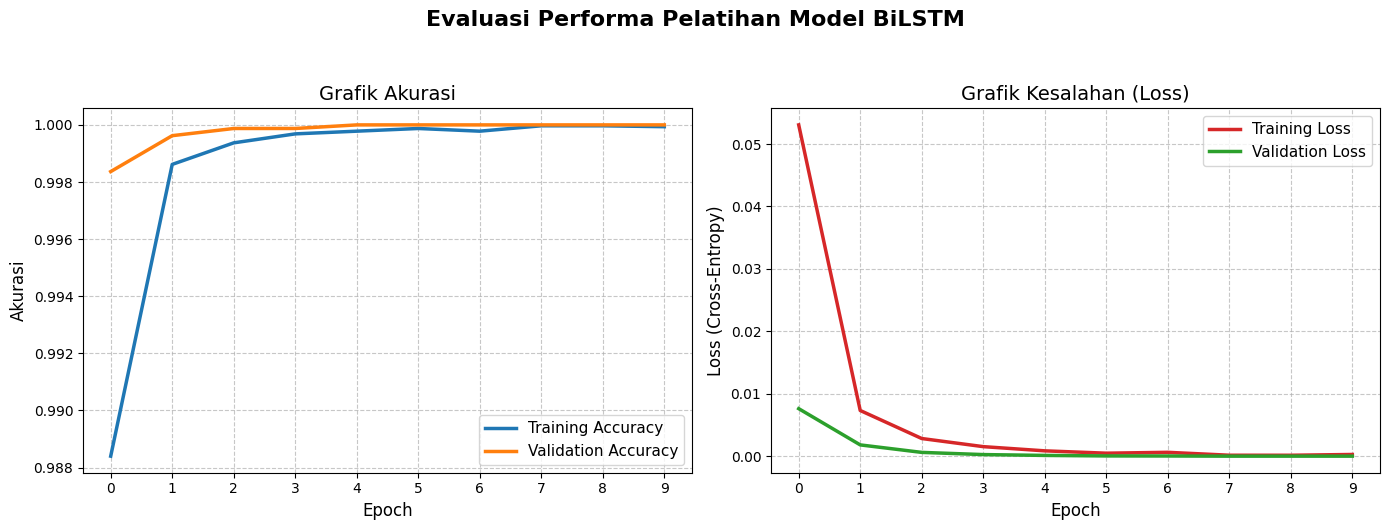


5. Melakukan Simulasi Deteksi Real-Time untuk ke-4 Keadaan...


🚨 LAPORAN DETEKSI KENDALI SUMUR (Confidence: 100.00%) 🚨
   [Label Aktual Data: KELAS 0 | Prediksi AI: KELAS 0]
STATUS : [KELAS 0] OPERASI NORMAL
ALASAN : Parameter sirkulasi hidrolik dan mekanis berada dalam rentang stabil. Tidak ada anomali signifikan pada pembacaan gas, volume pit, maupun laju aliran keluar.
SARAN MEKANISME :
  - Lanjutkan operasi pemboran sesuai parameter (ROP, WOB, RPM) saat ini.
  > DAMPAK: Operasi berjalan efisien menuju target kedalaman tanpa Non-Productive Time (NPT).

🚨 LAPORAN DETEKSI KENDALI SUMUR (Confidence: 100.00%) 🚨
   [Label Aktual Data: KELAS 1 | Prediksi AI: KELAS 1]
STATUS : [KELAS 1] FALSE ALARM (Connection Gas / Wellbore Ballooning)
ALASAN : Terdapat fluktuasi pada aliran keluar (Flow Out) dan/atau gas, namun berkorelasi dengan status pompa yang sedang mati. Ini merupakan efek U-Tube hidrostatik atau pengembangan formasi sesaat, bukan kick berkelanjutan.
SARAN MEKANISME :
  1. Circul

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD DATA & PREPARATION
# ==========================================
print("1. Memuat Data 3D untuk Pelatihan...")
try:
    X = np.load('X_features_30_timesteps.npy')
    y = np.load('y_target_labels.npy')
    print("   [SUKSES] Data berhasil dimuat!")
except FileNotFoundError:
    print("   [ERROR] File .npy tidak ditemukan. Pastikan script pembuat data sebelumnya sudah dijalankan.")
    exit()

# Split data: 80% Training, 20% Testing
# stratify=y memastikan proporsi kelas seimbang antara train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"   Bentuk input X_train: {X_train.shape} -> (Samples, Timesteps, Features)")
print(f"   Bentuk target y_train: {y_train.shape}")

# ==========================================
# 2. BANGUN ARSITEKTUR MODEL BiLSTM
# ==========================================
print("\n2. Membangun Arsitektur Model BiLSTM...")
model = Sequential([
    # Layer BiLSTM membaca urutan log sumur (maju dan mundur) untuk menangkap tren
    Bidirectional(LSTM(64, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3), # Dropout 30% untuk mencegah overfitting
    Dense(32, activation='relu'),
    # Output layer: 4 neuron sesuai jumlah kelas (Softmax untuk probabilitas)
    Dense(4, activation='softmax') 
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# ==========================================
# 3. TRAINING MODEL (10 EPOCHS)
# ==========================================
print("\n3. Memulai Pelatihan Model (10 Epochs)...")
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.2, # 20% dari data training digunakan untuk validasi
    verbose=1
)

# Simpan model
model.save('bilstm_blowout_detector_final.h5')
print("\n   [SUKSES] Model berhasil dilatih dan disimpan sebagai 'bilstm_blowout_detector_final.h5'")

# ==========================================
# 4. VISUALISASI HASIL PELATIHAN
# ==========================================
def plot_training_history(history):
    """Menampilkan grafik Akurasi dan Loss dari proses pelatihan."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Evaluasi Performa Pelatihan Model BiLSTM', fontsize=16, fontweight='bold', y=1.05)

    # Grafik Akurasi
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#1F77B4', linewidth=2.5)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF7F0E', linewidth=2.5)
    ax1.set_title('Grafik Akurasi', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Akurasi', fontsize=12)
    ax1.set_xticks(range(0, 10))
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Grafik Loss
    ax2.plot(history.history['loss'], label='Training Loss', color='#D62728', linewidth=2.5)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='#2CA02C', linewidth=2.5)
    ax2.set_title('Grafik Kesalahan (Loss)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
    ax2.set_xticks(range(0, 10))
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Panggil fungsi visualisasi
plot_training_history(history)

# ==========================================
# 5. SISTEM PAKAR (REASONING & RECOMMENDATION)
# ==========================================
def interpret_and_recommend(model_prediction, label_asli):
    """
    Sistem pendukung keputusan yang menjelaskan output AI.
    Menghasilkan Alasan, Saran, dan Dampak untuk ke-4 skenario.
    """
    kelas_prediksi = np.argmax(model_prediction)
    confidence = np.max(model_prediction) * 100
    
    print("\n" + "="*80)
    print(f"🚨 LAPORAN DETEKSI KENDALI SUMUR (Confidence: {confidence:.2f}%) 🚨")
    print(f"   [Label Aktual Data: KELAS {label_asli} | Prediksi AI: KELAS {kelas_prediksi}]")
    print("="*80)
    
    if kelas_prediksi == 0:
        print("STATUS : [KELAS 0] OPERASI NORMAL")
        print("ALASAN : Parameter sirkulasi hidrolik dan mekanis berada dalam rentang stabil. Tidak ada anomali signifikan pada pembacaan gas, volume pit, maupun laju aliran keluar.")
        print("SARAN MEKANISME :")
        print("  - Lanjutkan operasi pemboran sesuai parameter (ROP, WOB, RPM) saat ini.")
        print("  > DAMPAK: Operasi berjalan efisien menuju target kedalaman tanpa Non-Productive Time (NPT).")
        
    elif kelas_prediksi == 1:
        print("STATUS : [KELAS 1] FALSE ALARM (Connection Gas / Wellbore Ballooning)")
        print("ALASAN : Terdapat fluktuasi pada aliran keluar (Flow Out) dan/atau gas, namun berkorelasi dengan status pompa yang sedang mati. Ini merupakan efek U-Tube hidrostatik atau pengembangan formasi sesaat, bukan kick berkelanjutan.")
        print("SARAN MEKANISME :")
        print("  1. Circulate Bottoms Up (Lakukan sirkulasi penuh tanpa menambah kedalaman bor).")
        print("     > DAMPAK: Gas sisa sambungan akan terdorong keluar secara aman. Lubang menjadi bersih, namun menambah sedikit waktu NPT.")
        print("  2. Lakukan Flow Check (Pemantauan laju aliran statis selama 10-15 menit).")
        print("     > DAMPAK: Memastikan sumur benar-benar mati secara statis. Jika terbukti tidak ada aliran, pemboran sangat aman untuk dilanjutkan.")

    elif kelas_prediksi == 2:
        print("STATUS : [KELAS 2] LOST CIRCULATION (Waspada Bahaya Sekunder)")
        print("ALASAN : AI mendeteksi penurunan drastis secara beruntun pada Pit Volume dan Flow Out. Lumpur pemboran terindikasi hilang terserap ke dalam formasi (indikasi menembus zona rekahan atau porositas sangat tinggi).")
        print("SARAN MEKANISME :")
        print("  1. Turunkan kecepatan pompa (Pump Rate/SPM) secara bertahap.")
        print("     > DAMPAK: Mengurangi tekanan ECD (Equivalent Circulating Density) yang merobek formasi, namun efisiensi pengangkatan cutting (hole cleaning) bisa menurun.")
        print("  2. Pompakan material penyumbat (Lost Circulation Material / LCM).")
        print("     > DAMPAK: Menyumbat rekahan batuan agar sirkulasi lumpur kembali normal. Jika gagal dan volume terus anjlok, kolom hidrostatik akan berkurang dan berpotensi memicu Kick (Blowout sekunder).")

    elif kelas_prediksi == 3:
        print("STATUS : [KELAS 3] KRITIS - ACTUAL GAS KICK (BLOWOUT IMMINENT)")
        print("ALASAN : Terdeteksi pola invasi formasi! Terjadi Drilling Break (ROP naik tajam, Gamma Ray anjlok), dibarengi kenaikan Pit Volume kumulatif, Flow Out konstan di atas 100%, dan penurunan tekanan SPP akibat masuknya fluida gas yang lebih ringan.")
        print("SARAN MEKANISME :")
        print("  1. AKTIFKAN HARD SHUT-IN SEKARANG!")
        print("     - Hentikan putaran, matikan pompa, tutup Annular BOP, lalu buka katup HCR ke Choke Manifold secara perlahan.")
        print("     > DAMPAK: Menutup sumur seketika dan menghentikan aliran ke lantai rig. Memberikan waktu bagi Drilling Engineer untuk menghitung Kill Mud Weight dari tekanan SIDPP & SICP yang terakumulasi.")
        print("  2. Lakukan sirkulasi pematikan sumur (Driller's Method / Wait & Weight Method).")
        print("     > DAMPAK: Gas kick disirkulasikan keluar secara perlahan melalui choke dengan tekanan konstan. Sangat aman, namun memakan waktu operasi yang cukup lama.")
        print("  3. [Tindakan Darurat Ekstrim] Jika tekanan permukaan melewati batas aman MASP:")
        print("     - Aktifkan Blind Shear Rams dari panel akumulator.")
        print("     > DAMPAK: Rams akan memotong drill pipe secara paksa dan menutup sumur permanen. Menyelamatkan nyawa personel dan rig dari potensi ledakan blowout, namun drill string akan hancur.")
    print("="*80)

# ==========================================
# 6. SIMULASI DETEKSI REAL-TIME (4 SKENARIO)
# ==========================================
print("\n5. Melakukan Simulasi Deteksi Real-Time untuk ke-4 Keadaan...\n")

# Looping untuk mencari dan memprediksi masing-masing dari Kelas 0 hingga 3
for target_class in range(4):
    # Cari semua indeks di data testing yang memiliki label aktual sesuai target_class
    indices = np.where(y_test == target_class)[0]
    
    if len(indices) > 0:
        # Ambil satu sampel acak (indeks pertama) dari kelas tersebut
        sample_idx = indices[0] 
        
        # Ekstrak matriks input 3D untuk sampel tersebut: (30 timesteps, 9 features)
        data_input = X_test[sample_idx] 
        
        # Tambahkan dimensi batch agar sesuai dengan model -> (1, 30, 9)
        data_input_reshaped = np.expand_dims(data_input, axis=0) 
        
        # Prediksi menggunakan model BiLSTM yang sudah dilatih
        prediksi = model.predict(data_input_reshaped, verbose=0)
        
        # Tampilkan interpretasi
        interpret_and_recommend(prediksi, label_asli=target_class)
    else:
        print(f"\n[INFO] Tidak ada sampel untuk Kelas {target_class} di set pengujian.")

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import os

# ==========================================
# 1. LOAD MODEL BiLSTM YANG SUDAH DILATIH
# ==========================================
print("Memuat model BiLSTM...")
try:
    model = load_model('bilstm_blowout_detector_final.h5')
    print("✅ Model 'bilstm_blowout_detector_final.h5' berhasil dimuat!\n")
except Exception as e:
    print(f"❌ ERROR: Model tidak ditemukan. Pastikan file .h5 ada di direktori Anda.\nDetail: {e}")
    exit()

# Fitur yang digunakan saat pelatihan (harus sama persis urutannya)
fitur_input = ['Pump_Status', 'ROP_m_hr', 'SPP_psi', 'Flow_In_gpm', 
               'Flow_Out_pct', 'Pit_Volume_bbl', 'Total_Gas_pct', 
               'Gamma_Ray_API', 'Resistivity_ohm_m']

# ==========================================
# 2. SISTEM PAKAR (REASONING & RECOMMENDATION)
# ==========================================
def interpret_and_recommend(model_prediction, label_asli, filename):
    """Menerjemahkan probabilitas output AI menjadi rekomendasi operasional."""
    kelas_prediksi = np.argmax(model_prediction)
    confidence = np.max(model_prediction) * 100
    
    print("="*85)
    print(f"📄 MENGUJI FILE: {filename}")
    print(f"🚨 HASIL DETEKSI AI (Confidence: {confidence:.2f}%) 🚨")
    print(f"   [Ekspektasi Data: KELAS {label_asli} | Prediksi Model: KELAS {kelas_prediksi}]")
    print("="*85)
    
    # Evaluasi Kesesuaian Prediksi
    if kelas_prediksi == label_asli:
        print("✅ PREDIKSI TEPAT! Model berhasil mengenali pola anomali dengan benar.\n")
    else:
        print("❌ PREDIKSI KELIRU! Model gagal mengenali skenario ini.\n")

    if kelas_prediksi == 0:
        print("STATUS : [KELAS 0] OPERASI NORMAL")
        print("ALASAN : Parameter stabil. Tidak ada indikasi kick atau loss.")
        print("SARAN  : Lanjutkan pemboran sesuai parameter saat ini.")
        
    elif kelas_prediksi == 1:
        print("STATUS : [KELAS 1] FALSE ALARM (Connection Gas / Ballooning)")
        print("ALASAN : Fluktuasi flow out dan gas terdeteksi saat pompa mati. Ini efek U-Tube hidrostatik sesaat.")
        print("SARAN  : Lakukan Flow Check 15 menit. Jika sumur mati statis, lanjutkan operasi.")

    elif kelas_prediksi == 2:
        print("STATUS : [KELAS 2] LOST CIRCULATION")
        print("ALASAN : Volume Pit dan Flow Out anjlok tajam. Lumpur hilang ke formasi.")
        print("SARAN  : Turunkan SPM pompa, pompakan LCM (Lost Circulation Material). Waspada bahaya kick sekunder.")

    elif kelas_prediksi == 3:
        print("STATUS : [KELAS 3] KRITIS - ACTUAL GAS KICK (BLOWOUT IMMINENT)")
        print("ALASAN : Drilling break, Pit Volume naik kumulatif, Flow Out > 100%, SPP turun. Terjadi invasi formasi!")
        print("SARAN  : AKTIFKAN HARD SHUT-IN SEKARANG! Tutup Annular BOP, bersiap lakukan metode pematikan sumur.")
    print("="*85 + "\n")

# ==========================================
# 3. FUNGSI PENGUJIAN DATA BARU (INFERENCE)
# ==========================================
def test_scenario_on_model(csv_filename, expected_class, evaluation_row=550, window_size=30):
    """
    Membaca CSV, memproses data menjadi format 3D, dan melakukan prediksi.
    Kita akan mengambil window data tepat di baris terjadinya anomali.
    """
    try:
        df = pd.read_csv(csv_filename)
    except FileNotFoundError:
        print(f"❌ File {csv_filename} tidak ditemukan. Lewati...\n")
        return

    # Normalisasi Data (Di lapangan nyata, kita menggunakan Scaler yang di-save saat training)
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[fitur_input] = scaler.fit_transform(df[fitur_input])
    
    # Ekstrak data dari baris ke-(evaluation_row - window_size) hingga evaluation_row
    # Contoh: Baris 520 s.d 550. Posisi ini berada tepat di tengah-tengah anomali yang kita injeksi.
    start_idx = evaluation_row - window_size
    end_idx = evaluation_row
    
    # Ambil nilai array-nya
    X_window = df_scaled.loc[start_idx : end_idx - 1, fitur_input].values
    
    # Reshape menjadi 3D array (1 sample, 30 timesteps, 9 features)
    X_input_3d = np.expand_dims(X_window, axis=0)
    
    # Lakukan Prediksi
    prediksi = model.predict(X_input_3d, verbose=0)
    
    # Tampilkan Hasil
    interpret_and_recommend(prediksi, label_asli=expected_class, filename=csv_filename)

# ==========================================
# 4. EKSEKUSI PENGUJIAN KE-4 FILE
# ==========================================
# Kita tetapkan baris ke-550 sebagai titik evaluasi karena di baris ini, 
# semua event anomali (yang disuntikkan mulai baris 400) sedang aktif-aktifnya terjadi.

files_to_test = {
    "dataset_0_Normal.csv": 0,
    "dataset_1_False_Alarm.csv": 1,
    "dataset_2_Loss.csv": 2,
    "dataset_3_Kick.csv": 3
}

print("Memulai Pengujian Data Baru (Unseen Data)...\n")

for filename, true_class in files_to_test.items():
    test_scenario_on_model(csv_filename=filename, expected_class=true_class, evaluation_row=550)


Memuat model BiLSTM...

✅ Model 'bilstm_blowout_detector_final.h5' berhasil dimuat!

Memulai Pengujian Data Baru (Unseen Data)...

📄 MENGUJI FILE: dataset_0_Normal.csv
🚨 HASIL DETEKSI AI (Confidence: 93.42%) 🚨
   [Ekspektasi Data: KELAS 0 | Prediksi Model: KELAS 3]
❌ PREDIKSI KELIRU! Model gagal mengenali skenario ini.

STATUS : [KELAS 3] KRITIS - ACTUAL GAS KICK (BLOWOUT IMMINENT)
ALASAN : Drilling break, Pit Volume naik kumulatif, Flow Out > 100%, SPP turun. Terjadi invasi formasi!
SARAN  : AKTIFKAN HARD SHUT-IN SEKARANG! Tutup Annular BOP, bersiap lakukan metode pematikan sumur.

📄 MENGUJI FILE: dataset_1_False_Alarm.csv
🚨 HASIL DETEKSI AI (Confidence: 97.16%) 🚨
   [Ekspektasi Data: KELAS 1 | Prediksi Model: KELAS 2]
❌ PREDIKSI KELIRU! Model gagal mengenali skenario ini.

STATUS : [KELAS 2] LOST CIRCULATION
ALASAN : Volume Pit dan Flow Out anjlok tajam. Lumpur hilang ke formasi.
SARAN  : Turunkan SPM pompa, pompakan LCM (Lost Circulation Material). Waspada bahaya kick sekunder.

📄 

Memuat model BiLSTM...
✅ Model 'bilstm_blowout_detector_final.h5' berhasil dimuat!

Memulai Pengujian Visual (Inference) pada Data Baru...



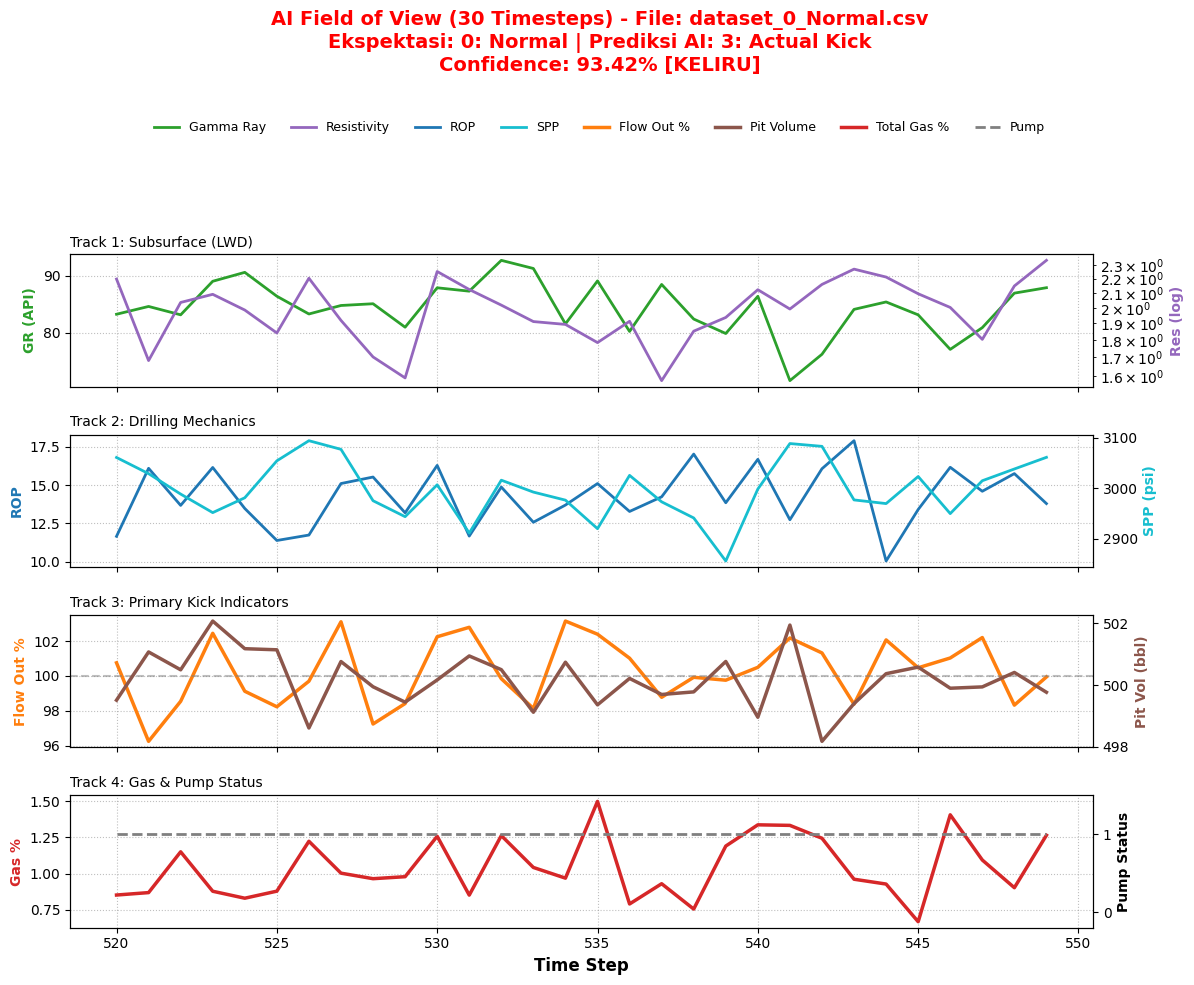

🚨 AI MENDETEKSI: ACTUAL GAS KICK (Confidence: 93.42%)
   SARAN: BAHAYA SEMBURAN LIAR! Aktifkan Hard Shut-In (Tutup Annular BOP) sekarang juga!



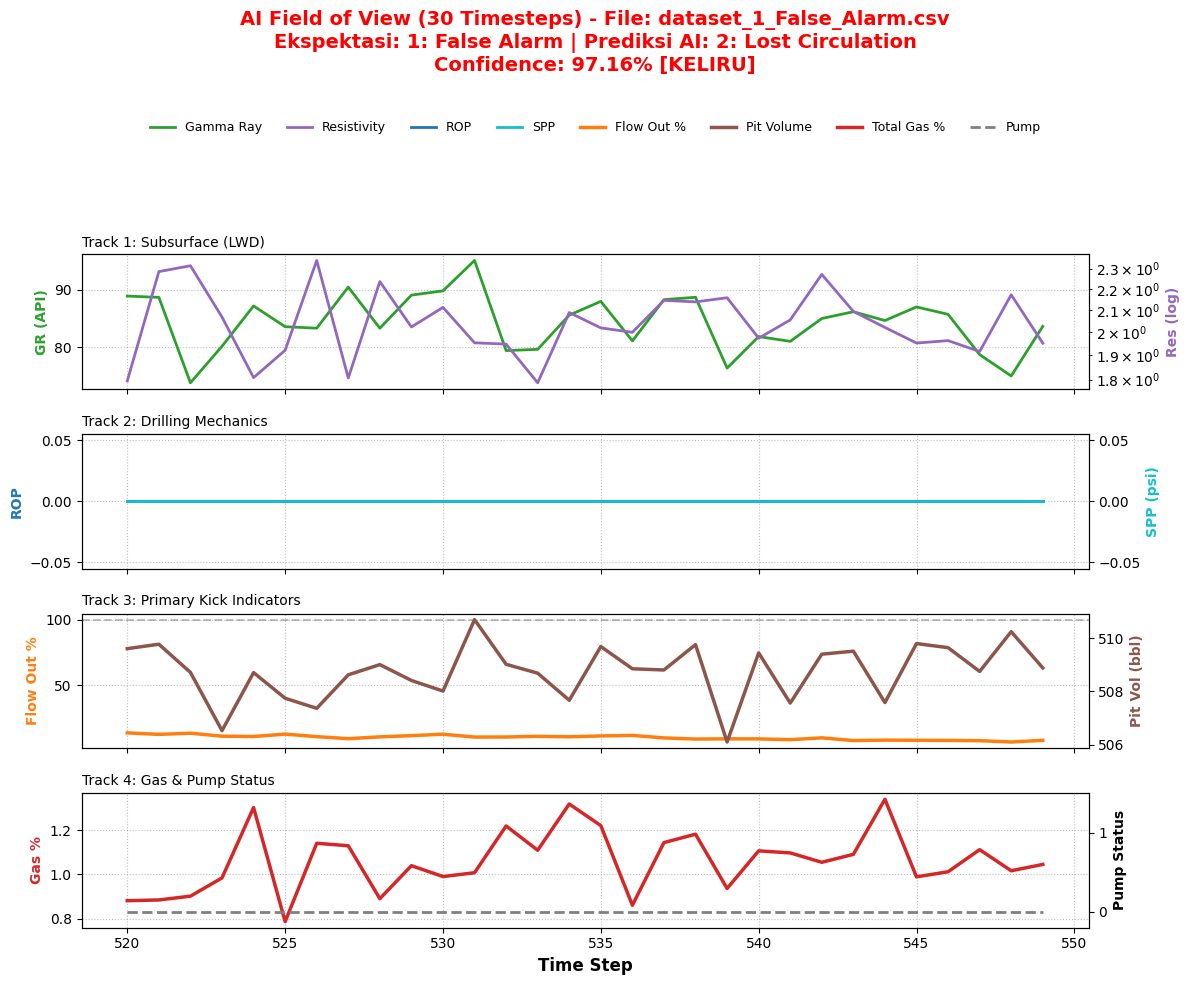

🔻 AI MENDETEKSI: LOST CIRCULATION (Confidence: 97.16%)
   SARAN: Pit volume anjlok. Turunkan SPM pompa, pompakan material penyumbat (LCM).



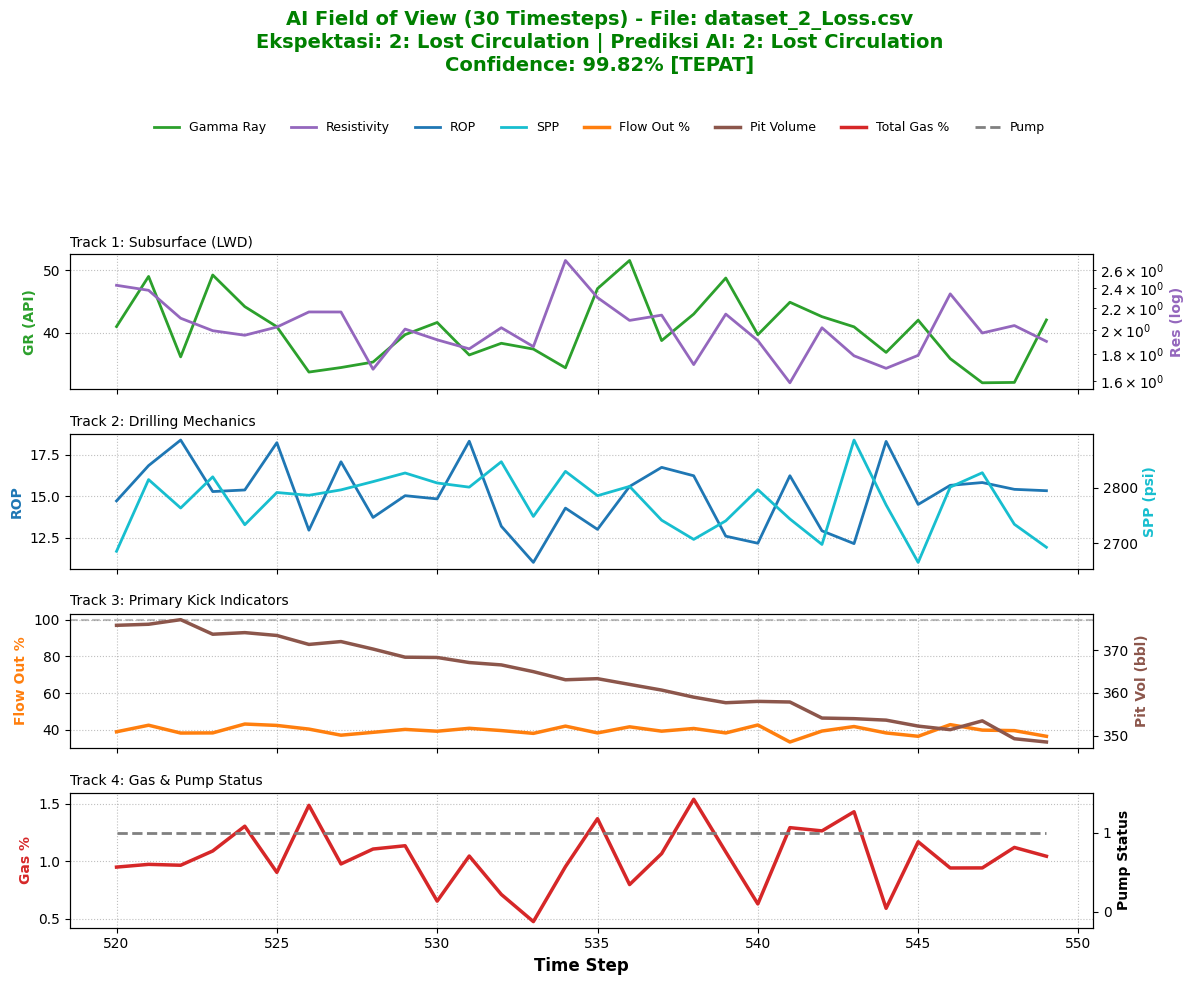

🔻 AI MENDETEKSI: LOST CIRCULATION (Confidence: 99.82%)
   SARAN: Pit volume anjlok. Turunkan SPM pompa, pompakan material penyumbat (LCM).



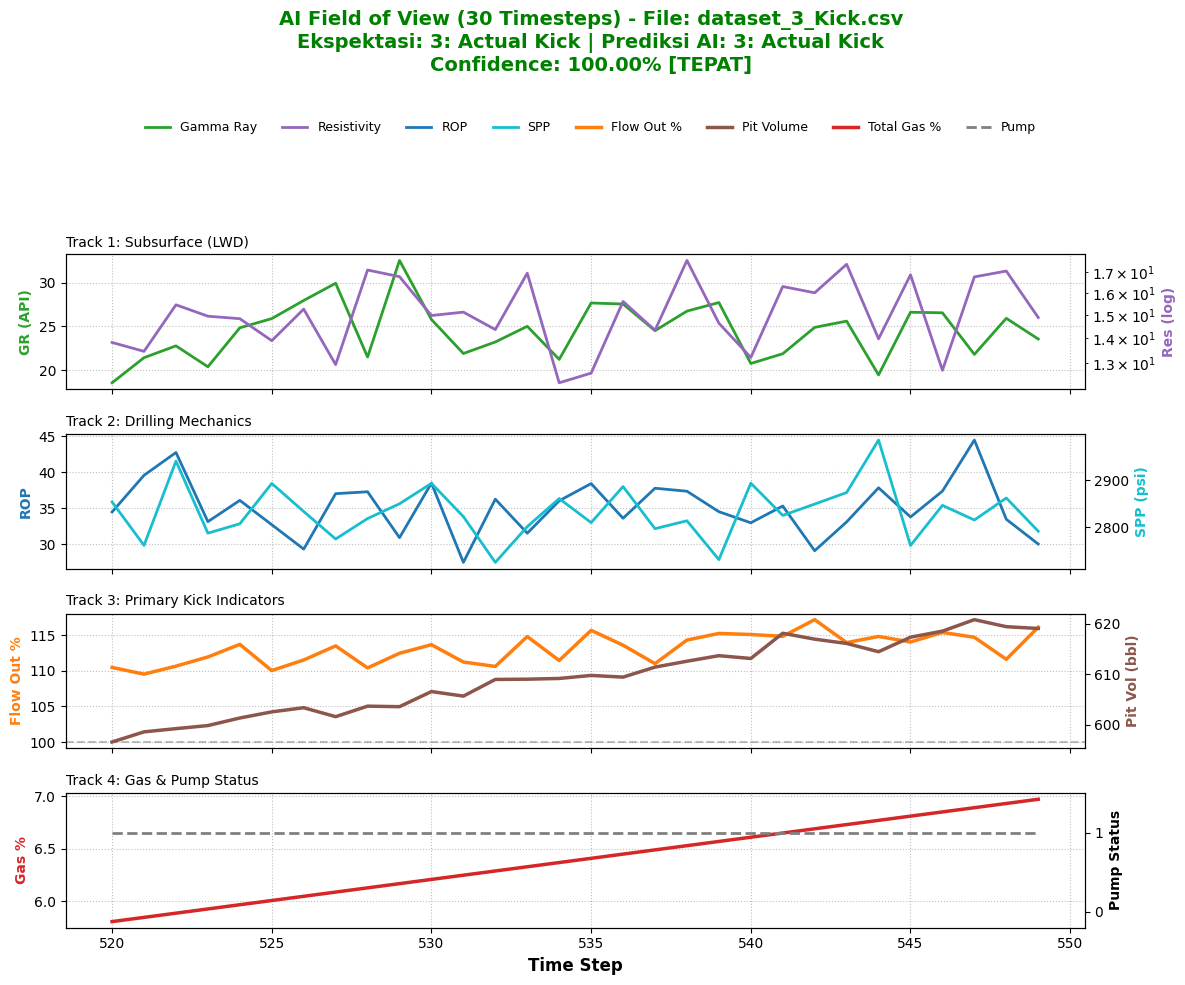

🚨 AI MENDETEKSI: ACTUAL GAS KICK (Confidence: 100.00%)
   SARAN: BAHAYA SEMBURAN LIAR! Aktifkan Hard Shut-In (Tutup Annular BOP) sekarang juga!



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import os

# ==========================================
# 1. LOAD MODEL BiLSTM
# ==========================================
print("Memuat model BiLSTM...")
try:
    model = load_model('bilstm_blowout_detector_final.h5')
    print("✅ Model 'bilstm_blowout_detector_final.h5' berhasil dimuat!\n")
except Exception as e:
    print(f"❌ ERROR: Model tidak ditemukan. Pastikan file .h5 ada di direktori Anda.\nDetail: {e}")
    exit()

fitur_input = ['Pump_Status', 'ROP_m_hr', 'SPP_psi', 'Flow_In_gpm', 
               'Flow_Out_pct', 'Pit_Volume_bbl', 'Total_Gas_pct', 
               'Gamma_Ray_API', 'Resistivity_ohm_m']

# Nama kelas untuk kemudahan visualisasi
nama_kelas = {
    0: "0: Normal",
    1: "1: False Alarm",
    2: "2: Lost Circulation",
    3: "3: Actual Kick"
}

# ==========================================
# 2. FUNGSI VISUALISASI JENDELA DATA (AI's VIEW)
# ==========================================
def plot_ai_window(df_window, filename, true_class, pred_class, confidence):
    """
    Menampilkan grafik khusus 30 timestep yang sedang dibaca oleh model AI,
    lengkap dengan hasil prediksinya di bagian judul.
    """
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    
    # Atur warna judul berdasarkan kebenaran prediksi
    title_color = 'green' if true_class == pred_class else 'red'
    status_text = "TEPAT" if true_class == pred_class else "KELIRU"
    
    fig.suptitle(f"AI Field of View (30 Timesteps) - File: {filename}\n"
                 f"Ekspektasi: {nama_kelas[true_class]} | Prediksi AI: {nama_kelas[pred_class]}\n"
                 f"Confidence: {confidence:.2f}% [{status_text}]", 
                 fontsize=14, fontweight='bold', color=title_color, y=0.98)
    
    time = df_window['Time_Step']

    # Track 1: LWD
    ax1 = axes[0]
    ax1.plot(time, df_window['Gamma_Ray_API'], color='#2CA02C', label='Gamma Ray', linewidth=2)
    ax1.set_ylabel('GR (API)', color='#2CA02C', fontweight='bold')
    ax1_twin = ax1.twinx()
    ax1_twin.plot(time, df_window['Resistivity_ohm_m'], color='#9467BD', label='Resistivity', linewidth=2)
    ax1_twin.set_yscale('log')
    ax1_twin.set_ylabel('Res (log)', color='#9467BD', fontweight='bold')
    ax1.set_title('Track 1: Subsurface (LWD)', fontsize=10, loc='left')

    # Track 2: Mekanis
    ax2 = axes[1]
    ax2.plot(time, df_window['ROP_m_hr'], color='#1F77B4', label='ROP', linewidth=2)
    ax2.set_ylabel('ROP', color='#1F77B4', fontweight='bold')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(time, df_window['SPP_psi'], color='#17BECF', label='SPP', linewidth=2)
    ax2_twin.set_ylabel('SPP (psi)', color='#17BECF', fontweight='bold')
    ax2.set_title('Track 2: Drilling Mechanics', fontsize=10, loc='left')

    # Track 3: Fluida
    ax3 = axes[2]
    ax3.plot(time, df_window['Flow_Out_pct'], color='#FF7F0E', label='Flow Out %', linewidth=2.5)
    ax3.axhline(100, color='grey', linestyle='--', alpha=0.5) # Garis batas normal 100%
    ax3.set_ylabel('Flow Out %', color='#FF7F0E', fontweight='bold')
    ax3_twin = ax3.twinx()
    ax3_twin.plot(time, df_window['Pit_Volume_bbl'], color='#8C564B', label='Pit Volume', linewidth=2.5)
    ax3_twin.set_ylabel('Pit Vol (bbl)', color='#8C564B', fontweight='bold')
    ax3.set_title('Track 3: Primary Kick Indicators', fontsize=10, loc='left')

    # Track 4: Gas & Status
    ax4 = axes[3]
    ax4.plot(time, df_window['Total_Gas_pct'], color='#D62728', label='Total Gas %', linewidth=2.5)
    ax4.set_ylabel('Gas %', color='#D62728', fontweight='bold')
    ax4_twin = ax4.twinx()
    ax4_twin.step(time, df_window['Pump_Status'], color='grey', linestyle='--', label='Pump', linewidth=2)
    ax4_twin.set_ylim(-0.2, 1.5)
    ax4_twin.set_yticks([0, 1])
    ax4_twin.set_ylabel('Pump Status', color='black', fontweight='bold')
    ax4.set_title('Track 4: Gas & Pump Status', fontsize=10, loc='left')
    ax4.set_xlabel('Time Step', fontsize=12, fontweight='bold')

    # Merapikan legend
    lines, labels = [], []
    for ax in [ax1, ax1_twin, ax2, ax2_twin, ax3, ax3_twin, ax4, ax4_twin]:
        axLine, axLabel = ax.get_legend_handles_labels()
        lines.extend(axLine)
        labels.extend(axLabel)
    fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.88), ncol=8, frameon=False, fontsize=9)

    for ax in axes:
        ax.grid(True, linestyle=':', alpha=0.5, color='grey')

    plt.tight_layout(rect=[0, 0, 1, 0.85], h_pad=1.5)
    plt.show()

# ==========================================
# 3. SISTEM PAKAR & INFERENCE
# ==========================================
def test_scenario_on_model(csv_filename, expected_class, evaluation_row=550, window_size=30):
    try:
        df = pd.read_csv(csv_filename)
    except FileNotFoundError:
        print(f"❌ File {csv_filename} tidak ditemukan. Lewati...\n")
        return

    # Normalisasi Data untuk Model (Model hanya menerima data terskala)
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[fitur_input] = scaler.fit_transform(df[fitur_input])
    
    # Ekstrak rentang indeks window (misal: 520 s.d 550)
    start_idx = evaluation_row - window_size
    end_idx = evaluation_row
    
    # 1. Ambil data terskala untuk dilempar ke Model AI
    X_window_scaled = df_scaled.loc[start_idx : end_idx - 1, fitur_input].values
    X_input_3d = np.expand_dims(X_window_scaled, axis=0)
    
    # 2. Ambil data asli (belum terskala) untuk divisualisasikan agar nilainya riil
    df_window_raw = df.loc[start_idx : end_idx - 1].copy()
    
    # Lakukan Prediksi
    prediksi = model.predict(X_input_3d, verbose=0)
    kelas_prediksi = np.argmax(prediksi)
    confidence = np.max(prediksi) * 100
    
    # Tampilkan Visualisasi
    plot_ai_window(df_window_raw, csv_filename, expected_class, kelas_prediksi, confidence)
    
    # Cetak Rekomendasi Sistem Pakar ke Terminal
    print("="*80)
    if kelas_prediksi == 0:
        print(f"✅ AI MENDETEKSI: NORMAL DRILLING (Confidence: {confidence:.2f}%)")
        print("   SARAN: Lanjutkan pemboran sesuai parameter. Lubang aman.")
    elif kelas_prediksi == 1:
        print(f"⚠️ AI MENDETEKSI: FALSE ALARM (Confidence: {confidence:.2f}%)")
        print("   SARAN: Pompa termonitor mati. Ini efek U-Tube hidrostatik sesaat. Lakukan Flow Check.")
    elif kelas_prediksi == 2:
        print(f"🔻 AI MENDETEKSI: LOST CIRCULATION (Confidence: {confidence:.2f}%)")
        print("   SARAN: Pit volume anjlok. Turunkan SPM pompa, pompakan material penyumbat (LCM).")
    elif kelas_prediksi == 3:
        print(f"🚨 AI MENDETEKSI: ACTUAL GAS KICK (Confidence: {confidence:.2f}%)")
        print("   SARAN: BAHAYA SEMBURAN LIAR! Aktifkan Hard Shut-In (Tutup Annular BOP) sekarang juga!")
    print("="*80 + "\n")

# ==========================================
# 4. EKSEKUSI PENGUJIAN KE-4 FILE
# ==========================================
files_to_test = {
    "dataset_0_Normal.csv": 0,
    "dataset_1_False_Alarm.csv": 1,
    "dataset_2_Loss.csv": 2,
    "dataset_3_Kick.csv": 3
}

print("Memulai Pengujian Visual (Inference) pada Data Baru...\n")

for filename, true_class in files_to_test.items():
    test_scenario_on_model(csv_filename=filename, expected_class=true_class, evaluation_row=550)